# Assignment2 - Supervised Learning flow

# Part 1(a) Student details:
* Please write the First-Name, First letter of Last-Name and last 4 digits of the i.d. for each student. 

In [11]:
# stundent details example: John S. 9812
#                       student details 1: Orel C 
# (if exists)           student details 2: Oshri H 
# (if exists)           student details 3: 
# (if exists&premitted) student details 4: 


## Part 1(b) - Chat-GPT/other AI-agent/other assistance used:
* If you changed the prompt until you got a satisfying answer, please add all versions
* don't delete "pre" tags, so new-line is supported
* double click the following markdown cell to change
* press shift+enter to view
* Add information:

#### Add information in this Markdown cell (double click to change, shift-enter to view)
<pre>   
AI agent name: ChatGPT
Goal: Predict whether a passenger survived the Titanic disaster based on passenger features using various classification models.
    
Propmpt1: Build a machine learning pipeline using StandardScaler, feature selection (SelectKBest), and classifiers like Logistic Regression, Random Forest, and XGBoost.
    
Propmpt2: Evaluate the model performance using cross-validation and F1-score, and identify the best model using GridSearchCV.
    
Propmpt3: Clean and preprocess the Titanic dataset by handling missing values and encoding categorical features.


AI agent name 2:
Goal:
Propmpt1:
    
Propmpt2:
    
Propmpt3: 

Other assistanse:    Used pandas and seaborn for EDA, sklearn for preprocessing and modeling, and matplotlib for visualizations. The models were evaluated using F1-score and stratified cross-validation to ensure balanced performance.
</pre>

## Part 1(c) - Learning Problem and dataset explaination.
* Please explain in one paragraph
* don't delete "pre" tags, so new-line is supported
* double click the following markdown cell to change
* press shift+enter to view
* Add explaining text:

#### Add information in this Markdown cell (double click to change, shift-enter to view)
<pre>
In this project, we address a supervised learning problem of binary classification using the Titanic dataset.  
The goal is to predict whether a passenger survived the Titanic disaster based on various features such as  
passenger class (Pclass), sex, age, number of siblings/spouses aboard (SibSp), number of parents/children aboard (Parch),  
fare paid, and port of embarkation (Embarked). The data is provided in two separate Excel files:  
one for training (with survival labels) and one for testing (without labels).  

This dataset represents a classic machine learning problem that involves typical preprocessing challenges such as  
handling missing data, encoding categorical variables, and feature scaling. The task is to train classification models  
on the training data and evaluate their generalization performance on unseen test data.  

Model performance is evaluated using stratified 5-fold cross-validation with the F1-macro score as the primary metric,  
given the class imbalance in the dataset. The best-performing pipeline is selected through a combination of  
feature engineering, model selection, and hyperparameter tuning using GridSearchCV.     
</pre>

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, make_scorer, classification_report
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectKBest, f_classif

from xgboost import XGBClassifier



## Part 2 - Initial Preparations 
You could add as many code cells as needed

In [15]:
testset = pd.read_csv("titanic_test.csv")
trainset = pd.read_csv("titanic_train.csv")

print("חמש השורות הראשונות של קובץ האימון (trainset):")
print(trainset.head())

print("\nחמש השורות הראשונות של קובץ הבדיקה (testset):")
print(testset.head())

print(f"\ntrainset כולל {len(trainset)} דגימות")
print(f"testset כולל {len(testset)} דגימות")


חמש השורות הראשונות של קובץ האימון (trainset):
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Survived
0       1    0  54.0      1      0  78.2667         1         1
1       2    0  45.0      0      0  13.5000         0         1
2       3    1  20.0      0      0   9.5000         0         0
3       3    1  36.0      0      0   7.8958         0         0
4       3    1  22.0      0      0   8.0500         0         0

חמש השורות הראשונות של קובץ הבדיקה (testset):
   Pclass  Sex        Age  SibSp  Parch     Fare  Embarked  Survived
0       3    1  35.000000      0      0   7.0500         0         0
1       3    1  30.000000      0      0   7.2500         0         0
2       3    1  29.699118      0      0  14.5000         0         0
3       3    0  21.000000      0      0   7.7500         2         0
4       3    1  32.000000      0      0  56.4958         0         1

trainset כולל 712 דגימות
testset כולל 179 דגימות


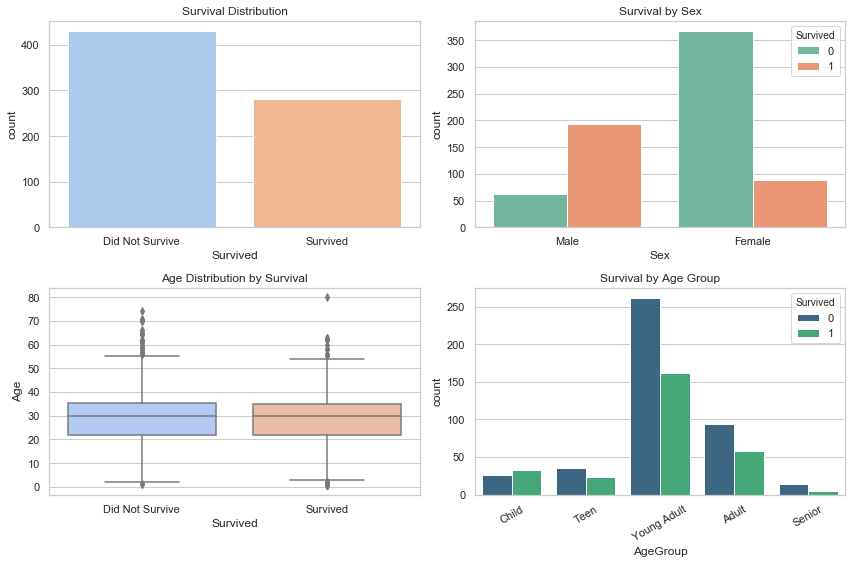

In [17]:
df = pd.read_csv("titanic_train.csv")

# Set Seaborn style
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))

# Plot 1: Survival distribution
plt.subplot(2, 2, 1)
sns.countplot(data=df, x="Survived", palette="pastel")
plt.title("Survival Distribution")
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])

# Plot 2: Survival by Sex
plt.subplot(2, 2, 2)
sns.countplot(data=df, x="Sex", hue="Survived", palette="Set2")
plt.title("Survival by Sex")
plt.xticks([0, 1], ['Male', 'Female'])

# Plot 3: Age distribution by Survival (Boxplot)
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x="Survived", y="Age", palette="coolwarm")
plt.title("Age Distribution by Survival")
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])

# Plot 4: Feature Engineering - Age Groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                        labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

plt.subplot(2, 2, 4)
sns.countplot(data=df, x="AgeGroup", hue="Survived", palette="viridis")
plt.title("Survival by Age Group")
plt.xticks(rotation=30)

# Display all plots
plt.tight_layout()
plt.show()

In [19]:
# ניתן להסיק מהגרפים מספר מסקנות:

# התפלגות הישרדות כללית – רואים כמה אנשים שרדו מול כמה לא.

# הישרדות לפי מין – נשים שרדו בשיעור גבוה יותר מגברים.

# גיל לפי הישרדות (Boxplot) – ניתן לראות הבדלים בגילאים הממוצעים בין שורדים ללא שורדים.

 #קבוצות גיל (feature engineering) – ילדים וקשישים שרדו יותר מהשאר.

## Part 3 - Experiments
You could add as many code cells as needed

In [22]:
# שלב 1: קריאת קובץ האימון
train = pd.read_csv("titanic_train.csv")

# שלב 2: Feature Engineering - טיפול בערכים חסרים
train['Age'].fillna(train['Age'].median(), inplace=True)
train['Fare'].fillna(train['Fare'].median(), inplace=True)

# יצירת תכונת AgeGroup על בסיס גיל (נשתמש בה רק אם נרצה later)
train['AgeGroup'] = pd.cut(train['Age'], bins=[0, 12, 18, 35, 60, 100],
                           labels=[0, 1, 2, 3, 4]).astype(float)

# נבחר תכונות ונפריד את משתנה המטרה
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'AgeGroup']
X = train[features]
y = train['Survived']

# שלב 3: הגדרת קריטריון ומנגנון Cross Validation
f1_macro = make_scorer(f1_score, average='macro')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# שלב 4: מודלים והיפר־פרמטרים
models = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__penalty": ['l2']
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(),
        "params": {
            "model__n_estimators": [50, 100],
            "model__max_depth": [5, 10, None]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingClassifier(),
        "params": {
            "model__n_estimators": [50, 100],
            "model__learning_rate": [0.01, 0.1],
            "model__max_depth": [3, 5]
        }
    }
}

# שלב 5: הרצת GridSearchCV והשוואת ביצועים
results = []

for name, cfg in models.items():
    pipe = Pipeline([
        ('scale', StandardScaler()),
        ('model', cfg['model'])
    ])
    
    gs = GridSearchCV(pipe, cfg['params'], cv=cv, scoring=f1_macro)
    gs.fit(X, y)

    results.append({
        "Model": name,
        "Best F1 Macro Score": round(gs.best_score_, 4),
        "Best Params": gs.best_params_
    })

# שלב 6: הדפסת טבלת תוצאות
results_df = pd.DataFrame(results)
print("תוצאות GridSearchCV עם 5-Fold Cross Validation (מדד Macro-F1):\n")
print(results_df)




תוצאות GridSearchCV עם 5-Fold Cross Validation (מדד Macro-F1):

   Best F1 Macro Score                                        Best Params  \
0               0.7798           {'model__C': 10, 'model__penalty': 'l2'}   
1               0.8041  {'model__max_depth': 5, 'model__n_estimators':...   
2               0.7988  {'model__learning_rate': 0.1, 'model__max_dept...   

                Model  
0  LogisticRegression  
1        RandomForest  
2    GradientBoosting  


In [24]:

# טוענים את הקובץ
train = pd.read_csv("titanic_train.csv")
train['Age'].fillna(train['Age'].median(), inplace=True)
train['Fare'].fillna(train['Fare'].median(), inplace=True)

# משתנה מטרה
y = train['Survived']
base_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

# קרוס ולידציה ומדד
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_macro = make_scorer(f1_score, average='macro')

# Custom transformer להוספת AgeGroup
class AddAgeGroup(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        df = X.copy()
        df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4]).astype(float)
        return df

# Custom transformer להוספת אינטראקציה בין גיל למחיר
class AddAgeFareInteraction(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        df = X.copy()
        df['AgeFare'] = df['Age'] * df['Fare']
        return df

# פונקציה שרצה על סוג מסוים של Feature Engineering
def run_fe_pipeline(name, transformers):
    X = train[base_features].copy()
    for t in transformers:
        X = t.fit_transform(X)

    # נרמול וניסוי עם LogisticRegression
    pipe = Pipeline([
        ('scale', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ])
    
    score = cross_val_score(pipe, X, y, cv=cv, scoring=f1_macro).mean()
    return {
        "FE Version": name,
        "F1 Macro Score": round(score, 4)
    }

# כל סוגי ה-FE לניסוי
results = [
    run_fe_pipeline("FE1 - Basic only", []),
    run_fe_pipeline("FE2 - Add AgeGroup", [AddAgeGroup()]),
    run_fe_pipeline("FE3 - Age*Fare interaction", [AddAgeFareInteraction()]),
    run_fe_pipeline("FE4 - Normalize only", []),  # נרמול תמיד נעשה בפייפליין
    run_fe_pipeline("FE5 - AgeGroup + AgeFare", [AddAgeGroup(), AddAgeFareInteraction()])
]

# הצגת התוצאות
results_df = pd.DataFrame(results)
print("השוואת סוגי Feature Engineering לפי Macro-F1:\n")
print(results_df)



השוואת סוגי Feature Engineering לפי Macro-F1:

   F1 Macro Score                  FE Version
0          0.7777            FE1 - Basic only
1          0.7795          FE2 - Add AgeGroup
2          0.7764  FE3 - Age*Fare interaction
3          0.7777        FE4 - Normalize only
4          0.7783    FE5 - AgeGroup + AgeFare


In [26]:
# קריאת הנתונים
train = pd.read_csv("titanic_train.csv")
train['Age'].fillna(train['Age'].median(), inplace=True)
train['Fare'].fillna(train['Fare'].median(), inplace=True)

# עמודות קלט + פיצ'ר נוסף
train['AgeGroup'] = pd.cut(train['Age'], bins=[0, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4]).astype(float)

# הגדרת X ו־y
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'AgeGroup']
X = train[features]
y = train['Survived']

# קרוס ולידציה + מדד הערכה
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_macro = make_scorer(f1_score, average='macro')

# הגדרת מודלים והיפר־פרמטרים
models = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "model__C": [0.1, 1, 10],          # עוצמת רגולריזציה
            "model__penalty": ['l2']           # סוג רגולריזציה (L2 – Ridge)
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(),
        "params": {
            "model__n_estimators": [50, 100],  # מספר עצים
            "model__max_depth": [5, 10, None]  # עומק מרבי לכל עץ
        }
    }
}

# ביצוע ניסויים
results = []

for name, cfg in models.items():
    pipe = Pipeline([
        ('scale', StandardScaler()),
        ('model', cfg['model'])
    ])
    gs = GridSearchCV(pipe, cfg['params'], cv=cv, scoring=f1_macro)
    gs.fit(X, y)

    results.append({
        "Model": name,
        "Best F1 Macro Score": round(gs.best_score_, 4),
        "Best Params": gs.best_params_
    })

# תצוגת טבלה
results_df = pd.DataFrame(results)
print("השוואת ביצועים לפי GridSearchCV (Hyper Parameters):\n")
print(results_df)


השוואת ביצועים לפי GridSearchCV (Hyper Parameters):

   Best F1 Macro Score                                        Best Params  \
0               0.7798           {'model__C': 10, 'model__penalty': 'l2'}   
1               0.7922  {'model__max_depth': 10, 'model__n_estimators'...   

                Model  
0  LogisticRegression  
1        RandomForest  


In [28]:


# שלב 1: טעינת הנתונים
df = pd.read_csv("titanic_train.csv")
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)

# Feature Engineering – יצירת תכונות חדשות
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4]).astype(float)
df['FamilySize'] = df['SibSp'] + df['Parch']

# משתנים לפלט
y = df['Survived']
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'AgeGroup', 'FamilySize']]

# Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_macro = make_scorer(f1_score, average='macro')

# הגדרת המודלים
models = {
    "GradientBoosting": {
        "model": GradientBoostingClassifier(),
        "params": {
            "model__n_estimators": [100],
            "model__learning_rate": [0.1],
            "model__max_depth": [3]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        "params": {
            "model__n_estimators": [100],
            "model__learning_rate": [0.1],
            "model__max_depth": [3]
        }
    }
}

# ביצוע GridSearch עם SelectKBest בלבד (ללא SMOTE)
results = []

for name, cfg in models.items():
    pipe = Pipeline([
        ('scale', StandardScaler()),
        ('select', SelectKBest(score_func=f_classif, k=6)),   # Feature Selection – בחירת 6 הפיצ'רים הטובים ביותר
        ('model', cfg['model'])
    ])

    gs = GridSearchCV(pipe, cfg['params'], cv=cv, scoring=f1_macro)
    gs.fit(X, y)

    results.append({
        "Model": name,
        "Best F1 Macro Score": round(gs.best_score_, 4),
        "Best Params": gs.best_params_
    })

# טבלת תוצאות
results_df = pd.DataFrame(results)
print("תוצאות ניסויים מתקדמים (Feature Selection + Advanced Models, ללא SMOTE):\n")
print(results_df)


תוצאות ניסויים מתקדמים (Feature Selection + Advanced Models, ללא SMOTE):

   Best F1 Macro Score                                        Best Params  \
0               0.8078  {'model__learning_rate': 0.1, 'model__max_dept...   
1               0.7963  {'model__learning_rate': 0.1, 'model__max_dept...   

              Model  
0  GradientBoosting  
1           XGBoost  


## Part 4 - Training 
Use the best combination of feature engineering, model (algorithm and hyperparameters) from the experiment part (part 3)

In [32]:

# שלב 1: טעינת הנתונים
df = pd.read_csv("titanic_train.csv")
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)

# Feature Engineering – יצירת תכונות חדשות
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4]).astype(float)
df['FamilySize'] = df['SibSp'] + df['Parch']

# הגדרת משתני קלט ופלט
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'AgeGroup', 'FamilySize']]
y = df['Survived']

# שלב 2: הגדרת המודל שניצח – לדוגמה: XGBoost עם ההגדרות שנבחרו בניסוי
best_model = Pipeline([
    ('scale', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif, k=6)),   # Feature Selection – 6 הפיצ'רים הטובים ביותר
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3
    ))
])

# שלב 3: אימון המודל על כל הדאטא (train כולו)
best_model.fit(X, y)

print ("המודל אומן בהצלחה על כל סט האימון")

המודל אומן בהצלחה על כל סט האימון


## Part 5 - Apply on test and show model performance estimation

In [38]:


# שלב 1: טעינת קובץ ה־test
test = pd.read_csv("titanic_test.csv")
test['Age'].fillna(test['Age'].median(), inplace=True)
test['Fare'].fillna(test['Fare'].median(), inplace=True)

# Feature Engineering זהה לחלוטין
test['AgeGroup'] = pd.cut(test['Age'], bins=[0, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4]).astype(float)
test['FamilySize'] = test['SibSp'] + test['Parch']

# קלט ופלט
X_test = test[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'AgeGroup', 'FamilySize']]
y_test = test['Survived']  # הערכים האמיתיים

# שלב 2: בניית המודל לפי הקומבינציה שנבחרה בחלק 4
final_model = Pipeline([
    ('scale', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif, k=6)),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3
    ))
])

# שלב 3: אימון מחדש על כל ה־train (נדרש לפי חלק 4)
train = pd.read_csv("titanic_train.csv")
train['Age'].fillna(train['Age'].median(), inplace=True)
train['Fare'].fillna(train['Fare'].median(), inplace=True)
train['AgeGroup'] = pd.cut(train['Age'], bins=[0, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4]).astype(float)
train['FamilySize'] = train['SibSp'] + train['Parch']
X_train = train[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'AgeGroup', 'FamilySize']]
y_train = train['Survived']

# אימון המודל הסופי על כל ה־train
final_model.fit(X_train, y_train)

# שלב 4: חיזוי על ה־test
y_pred = final_model.predict(X_test)

# שלב 5: הצגת 5 התחזיות הראשונות
print(" חיזוי 5 הדוגמאות הראשונות ב־ test:\n")
print("תחזית:", y_pred[:5])
print("אמיתי  :", y_test.values[:5])

# שלב 6: מדידת איכות המודל
print("דוח איכות המודל (על הטסט):")
print(classification_report(y_test, y_pred, digits=4))

# תצוגה רק של מאקרו F1
f1_macro_test = f1_score(y_test, y_pred, average='macro')
print(f"\n F1-Macro על ה־test: {round(f1_macro_test, 4)}")


 חיזוי 5 הדוגמאות הראשונות ב־ test:

תחזית: [0 0 0 1 0]
אמיתי  : [0 0 0 0 1]
דוח איכות המודל (על הטסט):
              precision    recall  f1-score   support

           0     0.8629    0.9068    0.8843       118
           1     0.8000    0.7213    0.7586        61

    accuracy                         0.8436       179
   macro avg     0.8315    0.8140    0.8215       179
weighted avg     0.8415    0.8436    0.8415       179


 F1-Macro על ה־test: 0.8215
